In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy.stats import skew, skewnorm
from helical_turbulence_models import helical_field_gs95, helical_field_kolmo, helical_field_random


In [ ]:
P, PHI, COS = helical_field_gs95(M_A=1, alpha=0, iaxis=2, g_size=256, anisotropy_strength=1.0, 
                                 seed=None, plotting=True)

In [ ]:
mach_vals = [0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.2,1.5,2,3]

plt.figure(figsize=(8,5))

for imach in mach_vals:
    P, PHI, C = helical_field_gs95(M_A=imach, alpha=0, iaxis=2, g_size=128, anisotropy_strength=1.0, 
                                 seed=None, plotting=False)
    plt.hist(P.flatten(), bins=30, alpha=0.5, label=f"{imach:.2f}", density=True, color = plt.cm.rainbow(mach_vals.index(imach)/len(mach_vals)))
plt.xlabel("P",fontsize=20)
plt.ylabel('Density',fontsize=20)
plt.legend(title=r'$M_A$')
plt.title(r'Helical Field; $\alpha$=0; axis=2; GS95',fontsize=20)


In [ ]:
plt.figure(figsize=(8, 5))
# mach_vals = [0.2,0.3, 0.4, 0.5,0.75,1,1.5,2,3]
mach_vals = [0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.2,1.5,2,3]

skews = []

for imach in mach_vals:

    # simulate
    P, PHI, C = helical_field_gs95(M_A=imach, alpha=0, iaxis=2, g_size=128, anisotropy_strength=1.0, 
                                 seed=None, plotting=False)
    # flatten & clip to >0
    Pflat = P.flatten()
    Pflat = Pflat[Pflat > 0]

    skew_val = skew(Pflat, bias=False)
    skews.append(skew_val)
    a, loc, scale = skewnorm.fit(Pflat)

    x = np.linspace(Pflat.min(), Pflat.max(), 300)
    pdf_skew = skewnorm.pdf(x, a, loc=loc, scale=scale)

    plt.hist(Pflat, bins=30, density=True, alpha=0.4, color = plt.cm.rainbow(mach_vals.index(imach)/len(mach_vals)))

    plt.plot(x, pdf_skew, lw=2, label=rf"$M_A={imach:.2f}$, skew={skew_val:.2f}", color = plt.cm.rainbow(mach_vals.index(imach)/len(mach_vals)))

plt.xlabel("P", fontsize=20)
plt.ylabel("Density", fontsize=20)
plt.title(r'Helical Field; $\alpha$=0; axis=2; GS95',fontsize=20)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


### Skewness vs. Alfvenic Mach Number

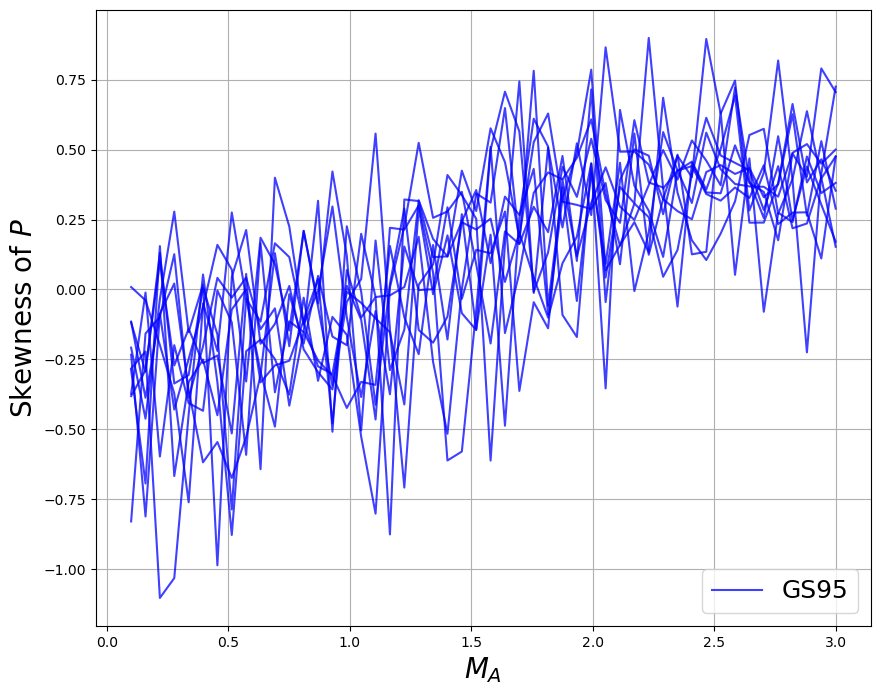

In [2]:
plt.figure(figsize=(10, 8))
n = 10
rng = np.random.default_rng()

for i in range(n):
    skews_gs95   = []
    # skews_gs95S  = []
    # skews_kolmo  = []
    # skews_random = []
    # skews_gs95_D = []

    mach_vals = np.linspace(0.1,3,50)
    # mach_vals = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0,3.5,4,4.5,5]

    for imach in mach_vals:
        seed = int(rng.integers(0, 2**31))

        P_GS, PHI_GS, C_GS = helical_field_gs95(M_A=imach, alpha=0, iaxis=2, g_size=64, anisotropy_strength=1.0, 
                                 seed=None, plotting=False)
        skews_gs95.append(skew(P_GS.flatten(), bias=False))

        # P_D, PHI_D, C_D = uniform_field_gs95(M_A=imach, Bz_true=0, angle_range=[0,np.pi/4], g_size=64, anisotropy_strength=1.0, seed=seed, plotting=False)
        # skews_gs95_D.append(skew(P_D.flatten(), bias=False))

        # P_K, PHI_K, C_K = uniform_field_kolmo(M_A=imach, Bz_true=0, angle_range=[np.pi/4,np.pi/4], g_size=64, plotting=False)
        # skews_kolmo.append(skew(P_K.flatten(), bias=False))

        # P_rand, PHI_rand, C_rand = uniform_field_random(M_A=imach, Bz_true=0, angle_range=[np.pi/4,np.pi/4], g_size=64, plotting=False)
        # skews_random.append(skew(P_rand.flatten(), bias=False))

    plt.plot(mach_vals, skews_gs95, linestyle='-', color = 'blue', alpha = 0.75, label='GS95' if i==0 else None)
    # plt.plot(mach_vals, skews_gs95_D, linestyle='-', color = 'cyan', alpha = 0.75, label='GS95 geo-depol' if i==0 else None)
    # plt.plot(mach_vals, skews_kolmo, linestyle='-', color = 'orange', alpha = 0.75, label='Kolmogorov' if i==0 else None)
    # plt.plot(mach_vals, skews_random, linestyle='-', color = 'magenta', alpha = 0.75, label='Random' if i==0 else None)
    
plt.xlabel(r"$M_A$", fontsize=20)
plt.ylabel("Skewness of $P$", fontsize=20)
plt.grid(True)
plt.legend(loc='lower right', fontsize=18)
plt.show()

### Skewness vs. Alfvenic Mach Number Fit and 1-sigma

In [3]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# --- tanh model ---
def model_tanh(x, a, b, c, d):
    return a * np.tanh(b * x + c) + d

# --- rational model ---
def model_rational(x, a, b, c, d):
    return a - b / (x**c + d)

# --- reciprocal model ---
def model_recip(x, a, b, c):
    return a - b * np.exp(-c * x) / x

def fit_and_summarise2(all_skews, mach_dense, color, label, fit_method='tanh'):
    """
    fit_method : 'tanh' or 'rational'
    """
    if fit_method == 'tanh':
        model   = model_tanh
        p0      = [1.0, 2.0, -1.0, 0.0]
        bounds  = (-np.inf, np.inf)
    elif fit_method == 'rational':
        model   = model_rational
        p0      = [0.6, 2.0, 1.0, 0.1]
        bounds  = ([0, 0, 0, 1e-6], [2, 10, 3, 1])  # keep c,d positive; avoid div/0
    elif fit_method == 'recip':
        model   = model_recip
        p0      = [0.6, 0.15, 8.0]
        bounds  = ([0.4, 0.01, 1.0], [1.2, 1.0,  20.0])
    else:
        raise ValueError(f"Unknown fit_method '{fit_method}'. Choose 'tanh' or 'rational'.")

    mean_skews = np.mean(all_skews, axis=0)

    popt, _ = curve_fit(model, mach_vals, mean_skews,
                        p0=p0, bounds=bounds, maxfev=10000)
    mean_fit = model(mach_dense, *popt)

    fitted_curves = []
    for run_skews in all_skews:
        try:
            popt_i, _ = curve_fit(model, mach_vals, run_skews,
                                  p0=popt, bounds=bounds, maxfev=10000)
            fitted_curves.append(model(mach_dense, *popt_i))
        except RuntimeError:
            print(f"  fit failed for a {label} run — skipping")

    fitted_curves = np.array(fitted_curves)
    std_fit = np.std(fitted_curves, axis=0)

    plt.plot(mach_dense, mean_fit, color=color, linewidth=2.5, label=label)
    plt.fill_between(mach_dense, mean_fit - std_fit, mean_fit + std_fit,
                     color=color, alpha=0.25)

  fit failed for a tanh fit run — skipping
  fit failed for a tanh fit run — skipping
  fit failed for a tanh fit run — skipping


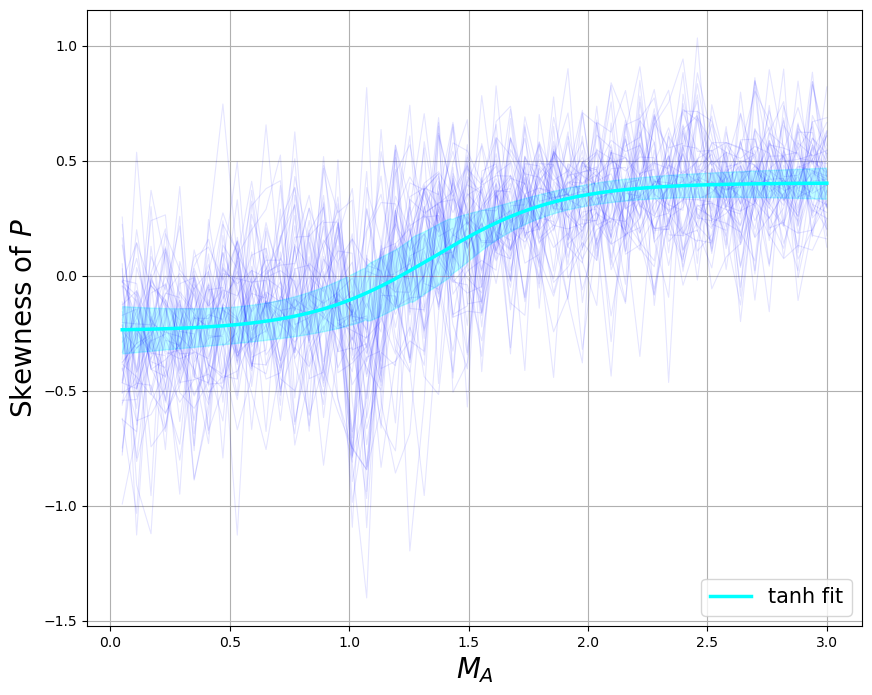

In [4]:
plt.figure(figsize=(10, 8))

n = 50
rng = np.random.default_rng()
mach_vals = np.linspace(0.05, 3, 50)

all_skews_gs95 = []

# --- Collect all n runs ---
for i in range(n):
    skews_gs95 = []
    for imach in mach_vals:
        seed = int(rng.integers(0, 2**31))
        P_GS, PHI_GS, C_GS = helical_field_gs95(M_A=imach, alpha=0, iaxis=2, g_size=64, anisotropy_strength=1.0, 
                                                seed=None, plotting=False)
        skews_gs95.append(skew(P_GS.flatten(), bias=False))
    all_skews_gs95.append(skews_gs95)

    # Faint raw traces
    plt.plot(mach_vals, skews_gs95, color='blue', alpha=0.1, linewidth=0.8)

all_skews_gs95 = np.array(all_skews_gs95)
mach_dense = np.linspace(mach_vals[0], mach_vals[-1], 300)

# ← switch between 'tanh' and 'rational' here
fit_and_summarise2(all_skews_gs95, mach_dense, color='cyan', label=r'tanh fit', fit_method='tanh')

plt.xlabel(r"$M_A$", fontsize=20)
plt.ylabel("Skewness of $P$", fontsize=20)
plt.grid(True)
plt.legend(loc='lower right', fontsize=15)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

all_skews_gs95   = np.array(all_skews_gs95)
# all_skews_gs95_D = np.array(all_skews_gs95_D)
# all_skews_kolmo  = np.array(all_skews_kolmo)

# mach_dense = np.linspace(mach_vals[0], mach_vals[-1], 300)

fit_and_summarise2(all_skews_gs95,   color='blue', label=r'GS95 $\pm 1\sigma$')
# fit_and_summarise2(all_skews_gs95_D, color='deepskyblue', label=r'GS95 geo-depol $\pm 1\sigma$')
# fit_and_summarise2(all_skews_kolmo,  color='aquamarine', label=r'Kolmogorov $\pm 1\sigma$')

plt.xlabel(r"$M_A$", fontsize=20)
plt.ylabel("Skewness of $P$", fontsize=20)
plt.grid(True)
plt.legend(loc='lower right', fontsize=15)
# plt.ylim(-2.2,1.2)
plt.show()

In [ ]:
# from scipy.optimize import curve_fit
# from scipy.stats import skew
# import numpy as np

# def aic(n, k, residuals):
#     """n = data points, k = free params, residuals = array of (y_data - y_fit)"""
#     sse = np.sum(residuals**2)
#     return n * np.log(sse / n) + 2 * k

# def bic(n, k, residuals):
#     sse = np.sum(residuals**2)
#     return n * np.log(sse / n) + k * np.log(n)

# # Define candidates
# def model_powerlaw(x, a, b, c):
#     return a * np.power(x, b) + c

# def model_tanh(x, a, b, c, d):
#     return a * np.tanh(b * x + c) + d

# def model_arctan(x, a, b, c, d):
#     return a * np.arctan(b * x + c) + d

# def model_hill(x, a, n, k, c):
#     return a * x**n / (k**n + x**n) + c

# models = {
#     'power law':  (model_powerlaw, [1, 1, 0]),
#     'tanh':       (model_tanh,     [1, 2, -1, 0]),
#     'arctan':     (model_arctan,   [1, 2, -1, 0]),
#     'hill':       (model_hill,     [1, 2, 1, 0]),
# }

# # Fit to the *mean* skewness across runs (or fit each run separately)
# mean_skews = np.mean(all_skews_gs95, axis=0)

# print(f"{'Model':<12} {'AIC':>8} {'BIC':>8} {'RMSE':>8}")
# print("-" * 40)
# for name, (func, p0) in models.items():
#     try:
#         popt, _ = curve_fit(func, mach_vals, mean_skews, p0=p0, maxfev=20000)
#         residuals = mean_skews - func(mach_vals, *popt)
#         n, k = len(mach_vals), len(popt)
#         print(f"{name:<12} {aic(n,k,residuals):>8.2f} {bic(n,k,residuals):>8.2f} {np.sqrt(np.mean(residuals**2)):>8.4f}")
#     except RuntimeError:
#         print(f"{name:<12}   fit failed")